# Fuel Price UK

In [31]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # HIdes harmless warning clutter


In [2]:
#Load the dataset

data = pd.read_csv("../data/price_history.csv")

In [3]:
#checking row and columns
data.shape 

(229232, 6)

In [4]:
#Checking the column names
data.columns

Index(['id', 'node_id', 'fuel_type', 'price_pence', 'recorded_at',
       'source_updated_at'],
      dtype='object')

In [5]:
# Checking the first 5 data
data.head()

,id,node_id,fuel_type,price_pence,recorded_at,source_updated_at
0,1,4882e3fee979cfefa29a8777ce57ca0ecea27b4f12ba7f...,E10,126.0,2026-02-07T21:40:01.511Z,2026-02-06T12:46:05.000Z
1,2,4882e3fee979cfefa29a8777ce57ca0ecea27b4f12ba7f...,B7_STANDARD,135.0,2026-02-07T21:40:01.511Z,2026-02-06T12:46:05.000Z
2,3,b739362af81acc9fec9eda6f155348125fa2d5c1772c96...,E10,127.0,2026-02-07T21:40:01.511Z,2026-02-01T11:04:45.000Z
3,4,b739362af81acc9fec9eda6f155348125fa2d5c1772c96...,B7_STANDARD,138.0,2026-02-07T21:40:01.511Z,2026-02-01T11:04:45.000Z
4,5,ae5b2f8f6979b8b2460ff52f85619dd0dfc6a10bc98ca1...,E5,146.0,2026-02-07T21:40:01.511Z,2026-02-06T13:57:50.000Z


In [6]:
#chekcing the bottom 5 data
data.tail()

,id,node_id,fuel_type,price_pence,recorded_at,source_updated_at
229227,229772,b4d4eaa2aaf0a5617a5e4d467bd65513bde7b4ccbc7c0f...,E10,149.9,2026-03-22T23:28:06.115Z,2026-03-22T23:25:29.000Z
229228,229773,b4d4eaa2aaf0a5617a5e4d467bd65513bde7b4ccbc7c0f...,B7_STANDARD,173.9,2026-03-22T23:28:06.115Z,2026-03-22T23:25:29.000Z
229229,229774,b4d4eaa2aaf0a5617a5e4d467bd65513bde7b4ccbc7c0f...,B7_PREMIUM,189.9,2026-03-22T23:28:06.115Z,2026-03-22T23:25:29.000Z
229230,229775,62934f040255eac8763683d845aa0daa974bba7018a1b4...,E10,146.9,2026-03-22T23:28:06.115Z,2026-03-22T23:26:45.000Z
229231,229776,62934f040255eac8763683d845aa0daa974bba7018a1b4...,B7_STANDARD,169.9,2026-03-22T23:28:06.115Z,2026-03-22T23:26:45.000Z


In [7]:
# Understanding the data type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229232 entries, 0 to 229231
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 229232 non-null  int64  
 1   node_id            229232 non-null  object 
 2   fuel_type          229232 non-null  object 
 3   price_pence        229232 non-null  float64
 4   recorded_at        229232 non-null  object 
 5   source_updated_at  229232 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 10.5+ MB


Here, the recorded_at and source_updated_at should be Date and time not object

In [8]:
# Fixing the date column in recorded_at

data['recorded_at'] = pd.to_datetime(data['recorded_at'])
data['source_updated_at'] = pd.to_datetime(data['source_updated_at'])

# Extracting the useful data type only 
data['date'] = data['recorded_at'].dt.date
data['hour'] = data['recorded_at'].dt.hour
data['day_of_week'] = data['recorded_at'].dt.day_name()
data['week'] = data['recorded_at'].dt.isocalendar().week


In [9]:
print("Date range of this dataset")
print(f"From:{data['recorded_at'].min()}")
print(f"From:{data['recorded_at'].max()}")

Date range of this dataset
From:2026-02-07 21:40:01.511000+00:00
From:2026-03-22 23:28:06.115000+00:00


This data covers roughly 44 days about 6 weeks of UK fuel prices across 7,442 stations.

In [10]:
# Check data quality
data.isnull().sum()

id                   0
node_id              0
fuel_type            0
price_pence          0
recorded_at          0
source_updated_at    0
date                 0
hour                 0
day_of_week          0
week                 0
dtype: int64

In [11]:
#Checking the price statistics
data['price_pence'].describe()

count    229232.000000
mean        153.733196
std          41.009238
min           0.000000
25%         140.000000
50%         149.900000
75%         163.900000
max        1949.000000
Name: price_pence, dtype: float64

1949 penny is so extreme it drags the mean upward for that fuel type. which cause wrong insight 

In [12]:
print("\n- SUSPICIOUS PRICES -")
print(f"Prices equal to 0 penny :{(data['price_pence'] == 0).sum()}")
print(f"Prices below 50 penny :{(data['price_pence'] < 50).sum()}")
print(f"Prices above 500 penny :{(data['price_pence'] > 500).sum()}")



- SUSPICIOUS PRICES -
Prices equal to 0 penny :2
Prices below 50 penny :494
Prices above 500 penny :327


- When Fuel Price is at 0 Penny

 A fuel price of zero penny is physically impossible. You cannot buy fuel for free. These are almost certainly one of two things: a system error where the station's pump failed to transmit a price, or a placeholder value inserted when no data was available.

- When Fule Price is at 50 penny

UK fuel has never been below 50p per litre in modern history. So these 494 records are not real prices. They likely come from stations entering prices in the wrong unit (pounds instead of pence), test entries from engineers setting up new stations, or corrupted transmissions. 

- When Fule Price is at 500 Penny

500p per litre would be £5.00 per litre — roughly 3x the real price. These are the opposite problem: values that are wildly too high. Same causes — unit errors, data corruption, or test data that never got cleaned out of the production system.

In [13]:
# Removing the bad data 

data_clean = data[data['price_pence']>=50 & (data['price_pence']<=400)].copy()
removed = len(data)-len(data_clean)

print(f"ORiginal rows:{len(data):,}")
print(f"Removed Rows:{removed:,}({removed/len(data)*100:.2f}% of the data)")
print(f"Clean rows:{len(data_clean):,}")
print(f"\nPrice range after cleaning:")
print(f"  Min: {data_clean['price_pence'].min():.1f}p")
print(f"  Max: {data_clean['price_pence'].max():.1f}p")
print(f"  Avg: {data_clean['price_pence'].mean():.1f}p")

ORiginal rows:229,232
Removed Rows:0(0.00% of the data)
Clean rows:229,232

Price range after cleaning:
  Min: 0.0p
  Max: 1949.0p
  Avg: 153.7p


why 50p and 400p > because real UK fuel prices in early 2026 sit in that band . anything price beside that are consider as data entry mistake 

In [14]:
# Cell 8 - Average price by fuel type
avg_by_fuel = data_clean.groupby('fuel_type')['price_pence'].agg(
     count='count',
     mean_price='mean',
     min_price='min',
     max_price='max'
).round(2).sort_values('mean_price', ascending=False)

print("AVERAGE PRICE BY FUEL TYPE (pence per litre)\n")
print(avg_by_fuel.to_string())

AVERAGE PRICE BY FUEL TYPE (pence per litre)

             count  mean_price  min_price  max_price
fuel_type                                           
B7_PREMIUM   35334      173.94       1.00     1949.0
HVO            321      165.61      11.61      444.0
E5           44064      157.48       0.00     1709.0
B7_STANDARD  80203      154.35       1.00     1777.0
B10            353      142.37       1.00      921.0
E10          68957      140.27       1.00     1479.0


max price can't be that high for all the fule price . it might be data entry mistake .

In [15]:
# Checking the exterme price properly 
print("Heighest prices in dataset \n")
print(data.nlargest(10,'price_pence')[['node_id','fuel_type','price_pence','recorded_at']])

Heighest prices in dataset 

                                                  node_id    fuel_type  \
130059  7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c08...   B7_PREMIUM   
212282  0c5dee22ecf242d1027b6118eac744e01755e080df95a1...  B7_STANDARD   
169547  3631dbafa225c68604b9d288cf0b44e26a14912ce713d8...  B7_STANDARD   
210995  91909366652067d23e82c14e9d55924d3ddf1549434440...  B7_STANDARD   
130056  7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c08...           E5   
3311    24c76ae2c22792c298a81faeccbf2874cf2e9549135fcf...           E5   
130058  7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c08...  B7_STANDARD   
137760  fa083c8f11b40cbf72156baaa440be52c841e40b51a637...  B7_STANDARD   
186125  d1496354a7989d8aaf8bc0dbe3cc3331c4d677dcd85544...  B7_STANDARD   
2919    05c79b55166e623e0f9f4de82fc6f00dd31329fc85a5ba...  B7_STANDARD   

        price_pence                      recorded_at  
130059       1949.0 2026-03-09 12:48:07.713000+00:00  
212282       1777.0 2026-03-20 18:12:06.829000

In [16]:
#chekcing the exterme records per fule type only 

print("Exterme recoreds per fule type\n ")
extreme_high = data[data['price_pence']>500]
print(extreme_high.groupby('fuel_type')['price_pence'].agg(['count','mean','max']))

Exterme recoreds per fule type
 
             count         mean     max
fuel_type                              
B10              2   722.450000   921.0
B7_PREMIUM      15  1285.386667  1949.0
B7_STANDARD     44  1352.287727  1777.0
E10            137  1062.823358  1479.0
E5             129  1063.530233  1709.0


In [17]:
# chekcing the price records per fule type below 50 penny 
print("records per fule type(belwo 50 penny)")
exterme_low = data[data['price_pence']<50]
print(exterme_low.groupby('fuel_type')['price_pence'].agg(['count','mean','max']))

records per fule type(belwo 50 penny)
             count       mean    max
fuel_type                           
B10             45  17.205556  31.31
B7_PREMIUM      67   3.970746  19.30
B7_STANDARD    135   7.428667  41.41
E10            136   3.746397  39.90
E5              97   7.590000  21.21
HVO             14  17.181429  17.61


In [18]:
#Does same stations have multiple bad price?

print("do same station have multiple bad prices ")
bad_stations = data[data['price_pence']>500]['node_id'].value_counts().head(10)
print(bad_stations)

do same station have multiple bad prices 
node_id
c9aa1695a016aa511c09299537f3c6536c428a1958eacaa21f2b545f455ecdb5    215
0eab9305ef5cfedf81d5b430c2050f50882997a00abc926d11a73ea36e5fe398      6
eb2a4ec0d0d85fbe3f6ea05566415571be7274212e00e16c2d003239e7930cf2      4
32e5e276d604141ace5e2af9358d1ba0d16cf0d31566f0e3e86c4fafb82b9c3e      4
9a8f20268e424c379929cbb3cf83925a2ab1b7dda461795f46a164192fd576aa      4
fdf4974536725227197fa9209fcfc82f234cfe342613b63cf72a100ec1dec152      4
523e6288311b2a2437084e803bd869932ba9969c7bcacf4aa11bee2e98f630a9      4
3c8b86979ee1c44d3b365287150ed428293c2190f349b9af6a4f595bcfe1dc95      4
8cc27e4c09366d7f6fc648c6c6d4eda8e069a70254c6687b291959417f57412d      4
7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c085565c92028a6f368ef      4
Name: count, dtype: int64


one station has 215 bad price records all by itself. every other station has only 4 - 6 . that single staion account tha more than 65% of all bad high price data out of 327 set. this might not be a random data entry mistake. it might be the cause of broken entyr sensor at that specifc staition that has been consistently transmitting garbage price .


In [19]:
# Deep dive into the problem station 

problem_station = 'c9aa1695a016aa511c09299537f3c6536c428a1958eacaa21f2b545f455ecdb5'

station_data = data[data['node_id']==problem_station]
print(f"total records for this stations: {len(station_data)}")
print(f"bad records (> 500penny):{len(station_data[station_data['price_pence']>500])}") # 500 penny vanda dheari liney petrol ko 
print(f"Good records (< 500penny):{len(station_data[station_data['price_pence']<500])}") # 500 penny vanda kaam liney



total records for this stations: 432
bad records (> 500penny):215
Good records (< 500penny):217


In [20]:
#Checking the fuel type which it sellls
station_data['fuel_type'].value_counts() #high price ma petrol dine station ko type of fuel 

fuel_type
E5             216
E10            213
B7_STANDARD      3
Name: count, dtype: int64

In [21]:
# Sample of bad prices 
bad_price = station_data[station_data['price_pence']>500][['fuel_type','price_pence','recorded_at']]
print(bad_price.sort_values('recorded_at').head(15))

      fuel_type  price_pence                      recorded_at
8506         E5       1000.0 2026-02-07 21:40:02.318000+00:00
8507        E10       1000.0 2026-02-07 21:40:02.318000+00:00
28018        E5       1000.0 2026-02-17 08:10:32.378000+00:00
28062        E5       1000.0 2026-02-17 08:57:03.384000+00:00
28078       E10       1000.0 2026-02-17 09:10:02.240000+00:00
28380        E5       1000.0 2026-02-17 11:52:34.734000+00:00
28473       E10       1000.0 2026-02-17 12:16:38.550000+00:00
28599        E5       1000.0 2026-02-17 12:40:53.969000+00:00
28614       E10       1000.0 2026-02-17 12:44:15.513000+00:00
28700        E5       1000.0 2026-02-17 13:25:11.607000+00:00
28778       E10       1000.0 2026-02-17 14:40:38.695000+00:00
29279        E5       1000.0 2026-02-17 17:53:07.771000+00:00
29576       E10       1000.0 2026-02-18 08:49:01.847000+00:00
29603        E5       1000.0 2026-02-18 09:52:08.104000+00:00
29751       E10       1000.0 2026-02-18 12:00:50.487000+00:00


In [22]:
#Sample of good price 
good_price = station_data[station_data['price_pence']<500][['fuel_type','price_pence','recorded_at']]
print(good_price.sort_values('recorded_at').head(15))

      fuel_type  price_pence                      recorded_at
27920        E5        124.0 2026-02-17 07:24:26.321000+00:00
28045        E5        124.0 2026-02-17 08:26:43.333000+00:00
28063       E10        138.0 2026-02-17 08:57:03.384000+00:00
28089        E5        124.0 2026-02-17 09:12:14.102000+00:00
28424       E10        138.0 2026-02-17 12:08:26.399000+00:00
28571        E5        124.0 2026-02-17 12:32:24.365000+00:00
28600       E10        138.0 2026-02-17 12:40:53.969000+00:00
28666        E5        124.0 2026-02-17 13:08:41.712000+00:00
28667       E10        138.0 2026-02-17 13:08:41.712000+00:00
29228        E5        124.0 2026-02-17 16:48:02.435000+00:00
29229       E10        138.0 2026-02-17 16:48:02.435000+00:00
29300        E5        124.0 2026-02-17 18:56:08.722000+00:00
29604       E10        138.0 2026-02-18 09:52:08.104000+00:00
29750        E5        124.0 2026-02-18 12:00:50.487000+00:00
29906       E10        138.0 2026-02-18 14:08:19.627000+00:00


In [23]:
#chekcing the bad prices happen at a specific time period bela 
station_data_copy = station_data.copy()
station_data_copy['is_bad'] = station_data_copy['price_pence'] >500
print(station_data_copy.groupby('is_bad')['recorded_at'].agg(['min','max']))

                                    min                              max
is_bad                                                                  
False  2026-02-17 07:24:26.321000+00:00 2026-03-22 09:48:04.096000+00:00
True   2026-02-07 21:40:02.318000+00:00 2026-03-20 15:56:13.631000+00:00


so, bad priceing was started form feb 7 and good price started from feb 17 after 10 days only . this station was transmitting bad dataq from day one . then at some point started sending some good prices too . 

In [24]:
# checking the cause and history over time 

problem_station = 'c9aa1695a016aa511c09299537f3c6536c428a1958eacaa21f2b545f455ecdb5'
station_data = data[data['node_id']==problem_station]
station_data = station_data.sort_values('recorded_at')
print(station_data[['fuel_type','price_pence','recorded_at']].to_string())

          fuel_type  price_pence                      recorded_at
8506             E5       1000.0 2026-02-07 21:40:02.318000+00:00
8507            E10       1000.0 2026-02-07 21:40:02.318000+00:00
27920            E5        124.0 2026-02-17 07:24:26.321000+00:00
28018            E5       1000.0 2026-02-17 08:10:32.378000+00:00
28045            E5        124.0 2026-02-17 08:26:43.333000+00:00
28062            E5       1000.0 2026-02-17 08:57:03.384000+00:00
28063           E10        138.0 2026-02-17 08:57:03.384000+00:00
28078           E10       1000.0 2026-02-17 09:10:02.240000+00:00
28089            E5        124.0 2026-02-17 09:12:14.102000+00:00
28380            E5       1000.0 2026-02-17 11:52:34.734000+00:00
28424           E10        138.0 2026-02-17 12:08:26.399000+00:00
28473           E10       1000.0 2026-02-17 12:16:38.550000+00:00
28571            E5        124.0 2026-02-17 12:32:24.365000+00:00
28599            E5       1000.0 2026-02-17 12:40:53.969000+00:00
28600     

it seems that price are not random garbage . they are alternative 1000/999 and perfectly normal price 123penny and 137 penny . sometime s within minutes of each other . and at the end of data at march 16 and march 20 suddendly new brand fuel type appears B7_STANDARD with perfect price . 

the sation wasn't broken it might be reconfigured 

In [25]:
# checking the pattern 
problem_station = 'c9aa1695a016aa511c09299537f3c6536c428a1958eacaa21f2b545f455ecdb5'
station_data = data[data['node_id'] == problem_station].copy()
station_data = station_data.sort_values('recorded_at')
print(station_data['price_pence'].value_counts()) #chekcing what price does this station transimt 

price_pence
999.9     177
137.9      90
123.7      86
1000.0     38
124.0      21
138.0      15
165.9       1
168.9       1
146.9       1
166.9       1
171.9       1
Name: count, dtype: int64


In [26]:
# Checking the fule types of this station timeline
print(station_data.groupby('fuel_type').agg(
     first_seen=('recorded_at', 'min'),
     last_seen=('recorded_at', 'max'),
     total_records=('price_pence', 'count'),
     bad_records=('price_pence', lambda x: (x > 500).sum()),
     normal_records=('price_pence', lambda x: (x <= 500).sum())
))


                                  first_seen                        last_seen  \
fuel_type                                                                       
B7_STANDARD 2026-03-16 15:04:01.257000+00:00 2026-03-22 09:48:04.096000+00:00   
E10         2026-02-07 21:40:02.318000+00:00 2026-03-20 17:16:06.453000+00:00   
E5          2026-02-07 21:40:02.318000+00:00 2026-03-20 18:04:01.916000+00:00   

             total_records  bad_records  normal_records  
fuel_type                                                
B7_STANDARD              3            0               3  
E10                    213          107             106  
E5                     216          108             108  


In [27]:
#checking the last records from the satation
print(station_data.tail(10)[['fuel_type','price_pence','recorded_at']])

          fuel_type  price_pence                      recorded_at
207226           E5        999.9 2026-03-20 11:40:21.161000+00:00
208063          E10        137.9 2026-03-20 12:44:07.434000+00:00
208488          E10        999.9 2026-03-20 13:48:07.567000+00:00
208941           E5        123.7 2026-03-20 14:52:01.774000+00:00
208942          E10        137.9 2026-03-20 14:52:01.774000+00:00
210636          E10        999.9 2026-03-20 15:56:13.631000+00:00
210951  B7_STANDARD        168.9 2026-03-20 16:28:08.960000+00:00
211840          E10        146.9 2026-03-20 17:16:06.453000+00:00
212150           E5        166.9 2026-03-20 18:04:01.916000+00:00
223903  B7_STANDARD        171.9 2026-03-22 09:48:04.096000+00:00


In [28]:
# Final cleaning with full documentation 

data_clean = data[
    (data['price_pence'] >= 50) &
    (data['price_pence'] < 500)
].copy()

removed = len(data) - len(data_clean)

print("=== CLEANING COMPLETE ===")
print(f"Original rows : {len(data):>10,}")
print(f"Removed rows  : {removed:>10,}  ({removed/len(data)*100:.2f}%)")
print(f"Clean rows    : {len(data_clean):>10,}")
print(f"\nPrice range after cleaning:")
print(f"  Min : {data_clean['price_pence'].min():.1f}p")
print(f"  Max : {data_clean['price_pence'].max():.1f}p")
print(f"  Mean: {data_clean['price_pence'].mean():.1f}p")

print("\n=== CLEAN AVERAGE BY FUEL TYPE ===")
print(data_clean.groupby('fuel_type')['price_pence'].agg(
    count='count',
    mean='mean',
    min='min',
    max='max'
).round(2).sort_values('mean', ascending=False))

=== CLEANING COMPLETE ===
Original rows :    229,232
Removed rows  :        825  (0.36%)
Clean rows    :    228,407

Price range after cleaning:
  Min : 50.5p
  Max : 490.0p
  Mean: 152.7p

=== CLEAN AVERAGE BY FUEL TYPE ===
             count    mean    min    max
fuel_type                               
B7_PREMIUM   35252  173.79   50.5  333.3
HVO            307  172.38   60.6  444.0
B10            306  156.98   54.0  323.9
E5           43838  155.15  101.9  444.4
B7_STANDARD  80021  153.93   90.0  444.4
E10          68683  138.69   87.0  490.0


## Chart Visualization 


# bar chart average price by fuel type

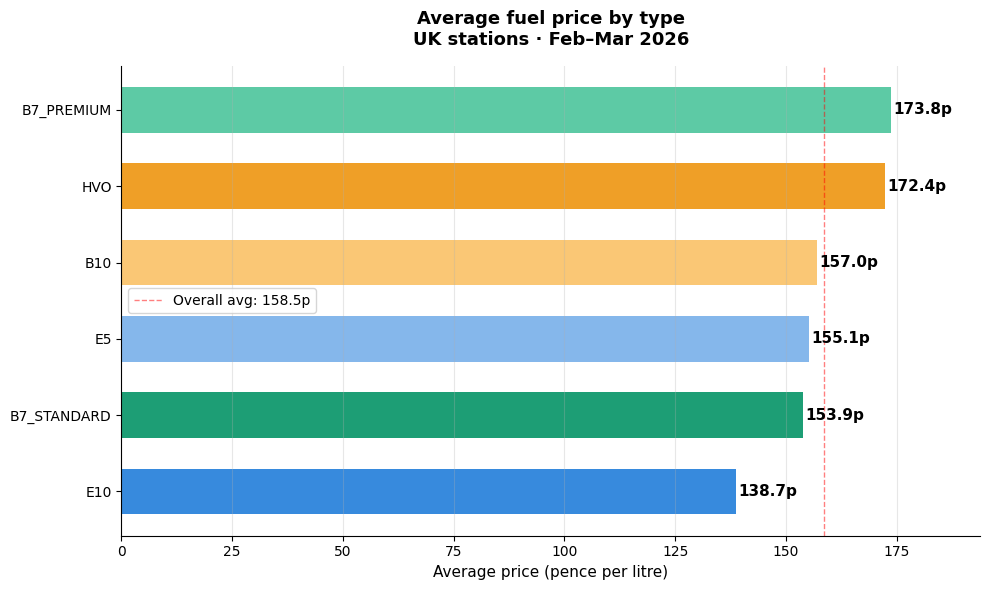

Chart saved as chart1_avg_price.png


In [34]:
# Chart 1: Average price by fuel type
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate data
fuel_avg = data_clean.groupby('fuel_type')['price_pence'].mean().sort_values(ascending=True)

# Define colors - highlight the two most common fuels
colors = {
    'E10':          '#378ADD',   # blue  - most common petrol
    'E5':           '#85B7EB',   # light blue
    'B7_STANDARD':  '#1D9E75',   # green - most common diesel
    'B7_PREMIUM':   '#5DCAA5',   # light green
    'HVO':          '#EF9F27',   # amber - renewable
    'B10':          '#FAC775',   # light amber
}
bar_colors = [colors[fuel] for fuel in fuel_avg.index]

# Draw bars
bars = ax.barh(fuel_avg.index, fuel_avg.values, color=bar_colors, height=0.6)

# Add value labels on each bar
for bar, val in zip(bars, fuel_avg.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}p', va='center', ha='left', fontsize=11, fontweight='bold')

# Formatting
ax.set_xlabel('Average price (pence per litre)', fontsize=11)
ax.set_title('Average fuel price by type\nUK stations · Feb–Mar 2026', 
                fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, fuel_avg.max() + 20)
ax.axvline(x=fuel_avg.mean(), color='red', linestyle='--', 
            linewidth=1, alpha=0.5, label=f'Overall avg: {fuel_avg.mean():.1f}p')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/chart1_avg_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as chart1_avg_price.png")

### Box plot : price distribution 

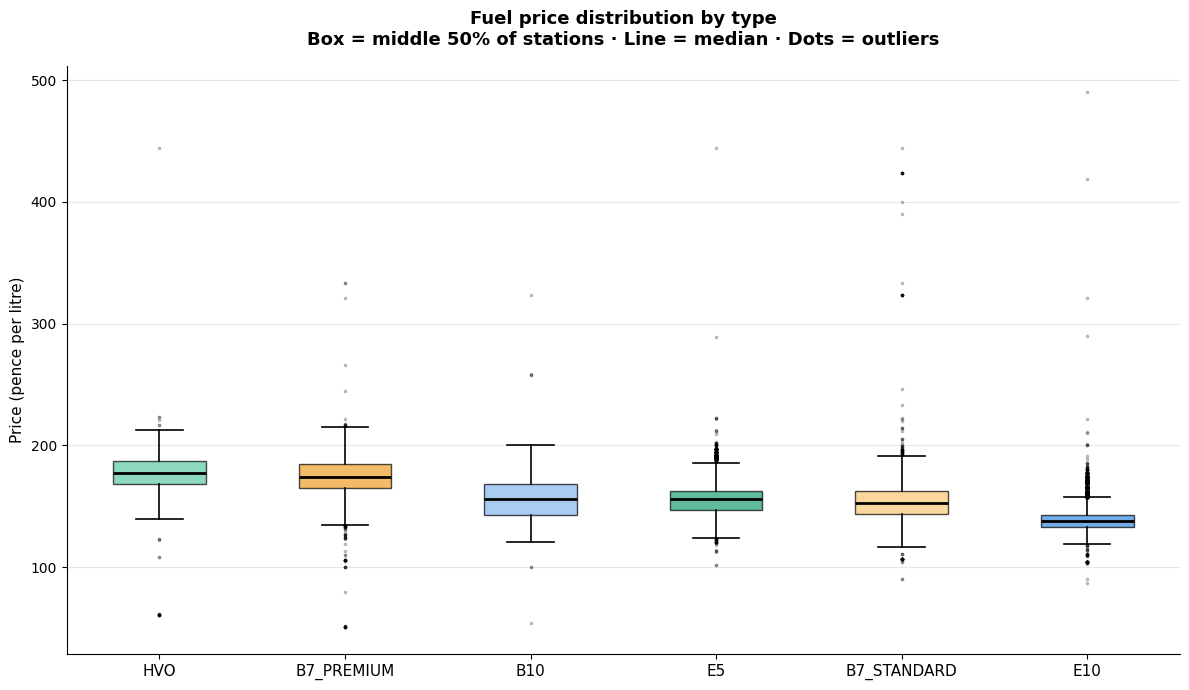

Chart saved as chart2_distribution.png


In [39]:
# - Chart 2: Box plot - price distribution per fuel type
fig, ax = plt.subplots(figsize=(12, 7))

# Order fuel types by median price
order = data_clean.groupby('fuel_type')['price_pence'].median()\
                .sort_values(ascending=False).index.tolist()

# Draw box plot
data_to_plot = [data_clean[data_clean['fuel_type'] == f]['price_pence'].values 
                for f in order]

bp = ax.boxplot(data_to_plot, 
                labels=order,
                patch_artist=True,
                notch=False,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='.', markersize=3, 
                               alpha=0.3, color='gray'))

# Color each box
box_colors = ['#5DCAA5', '#EF9F27', '#85B7EB', '#1D9E75', '#FAC775', '#378ADD']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Formatting
ax.set_ylabel('Price (pence per litre)', fontsize=11)
ax.set_title('Fuel price distribution by type\nBox = middle 50% of stations · Line = median · Dots = outliers',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(order, fontsize=11)

plt.tight_layout()
plt.savefig('../figures/chart2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as chart2_distribution.png")

### Line chart how prices changed over time 

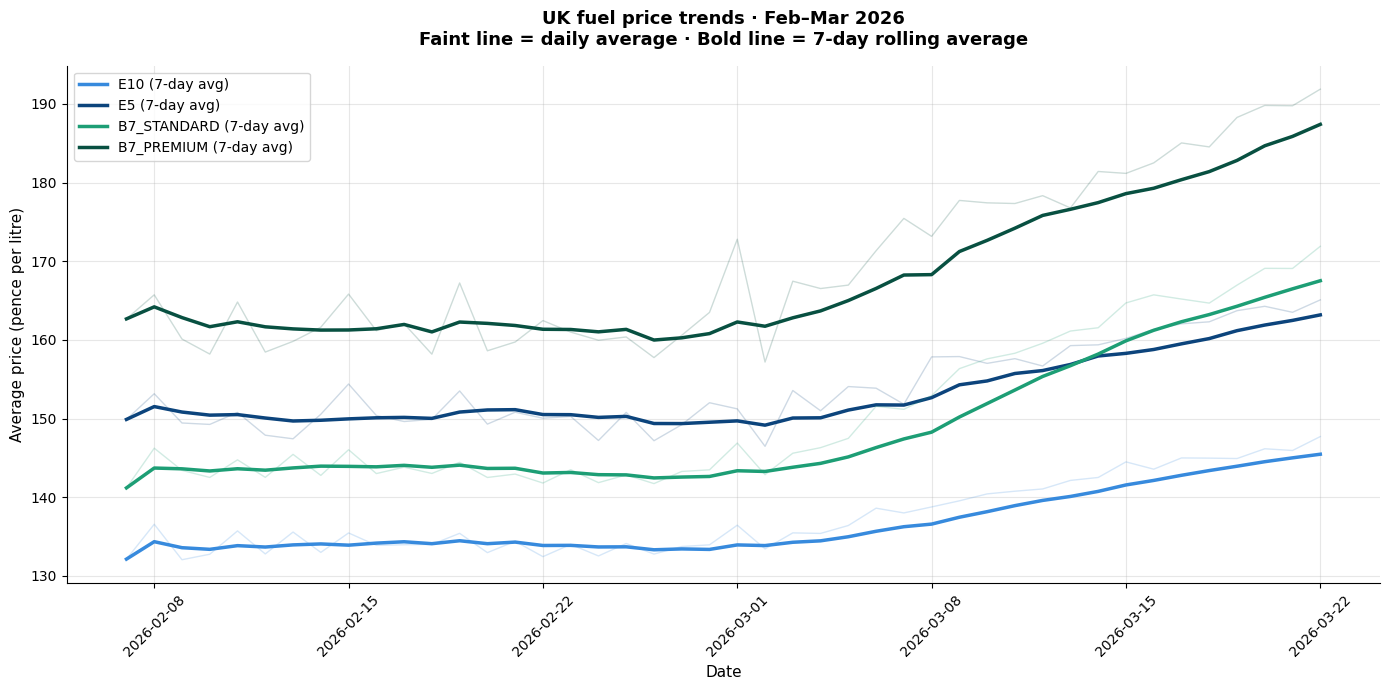

Chart saved as chart3_trends.png


In [42]:
#- Chart 3: Price trend over time
fig, ax = plt.subplots(figsize=(14, 7))

# Focus on the 4 main fuel types (exclude HVO and B10 - too few stations)
main_fuels = ['E10', 'E5', 'B7_STANDARD', 'B7_PREMIUM']
colors_line = {
    'E10':         '#378ADD',
    'E5':          '#0C447C', 
    'B7_STANDARD': '#1D9E75',
    'B7_PREMIUM':  '#085041',
}

for fuel in main_fuels:
    fuel_data = data_clean[data_clean['fuel_type'] == fuel].copy()
    
    # Daily average
    daily = fuel_data.groupby('date')['price_pence'].mean().reset_index()
    daily['date'] = pd.to_datetime(daily['date'])
    
    # Plot raw daily average (faint)
    ax.plot(daily['date'], daily['price_pence'], 
            color=colors_line[fuel], alpha=0.2, linewidth=1)
    
    # Plot 7-day rolling average (bold) - this is the real trend
    daily['rolling'] = daily['price_pence'].rolling(window=7, min_periods=1).mean()
    ax.plot(daily['date'], daily['rolling'],
            color=colors_line[fuel], linewidth=2.5, 
            label=f"{fuel} (7-day avg)")

# Formatting
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Average price (pence per litre)', fontsize=11)
ax.set_title('UK fuel price trends · Feb–Mar 2026\nFaint line = daily average · Bold line = 7-day rolling average',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

# Rotate x labels
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/chart3_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as chart3_trends.png")

### All 4 charts in one dashboard

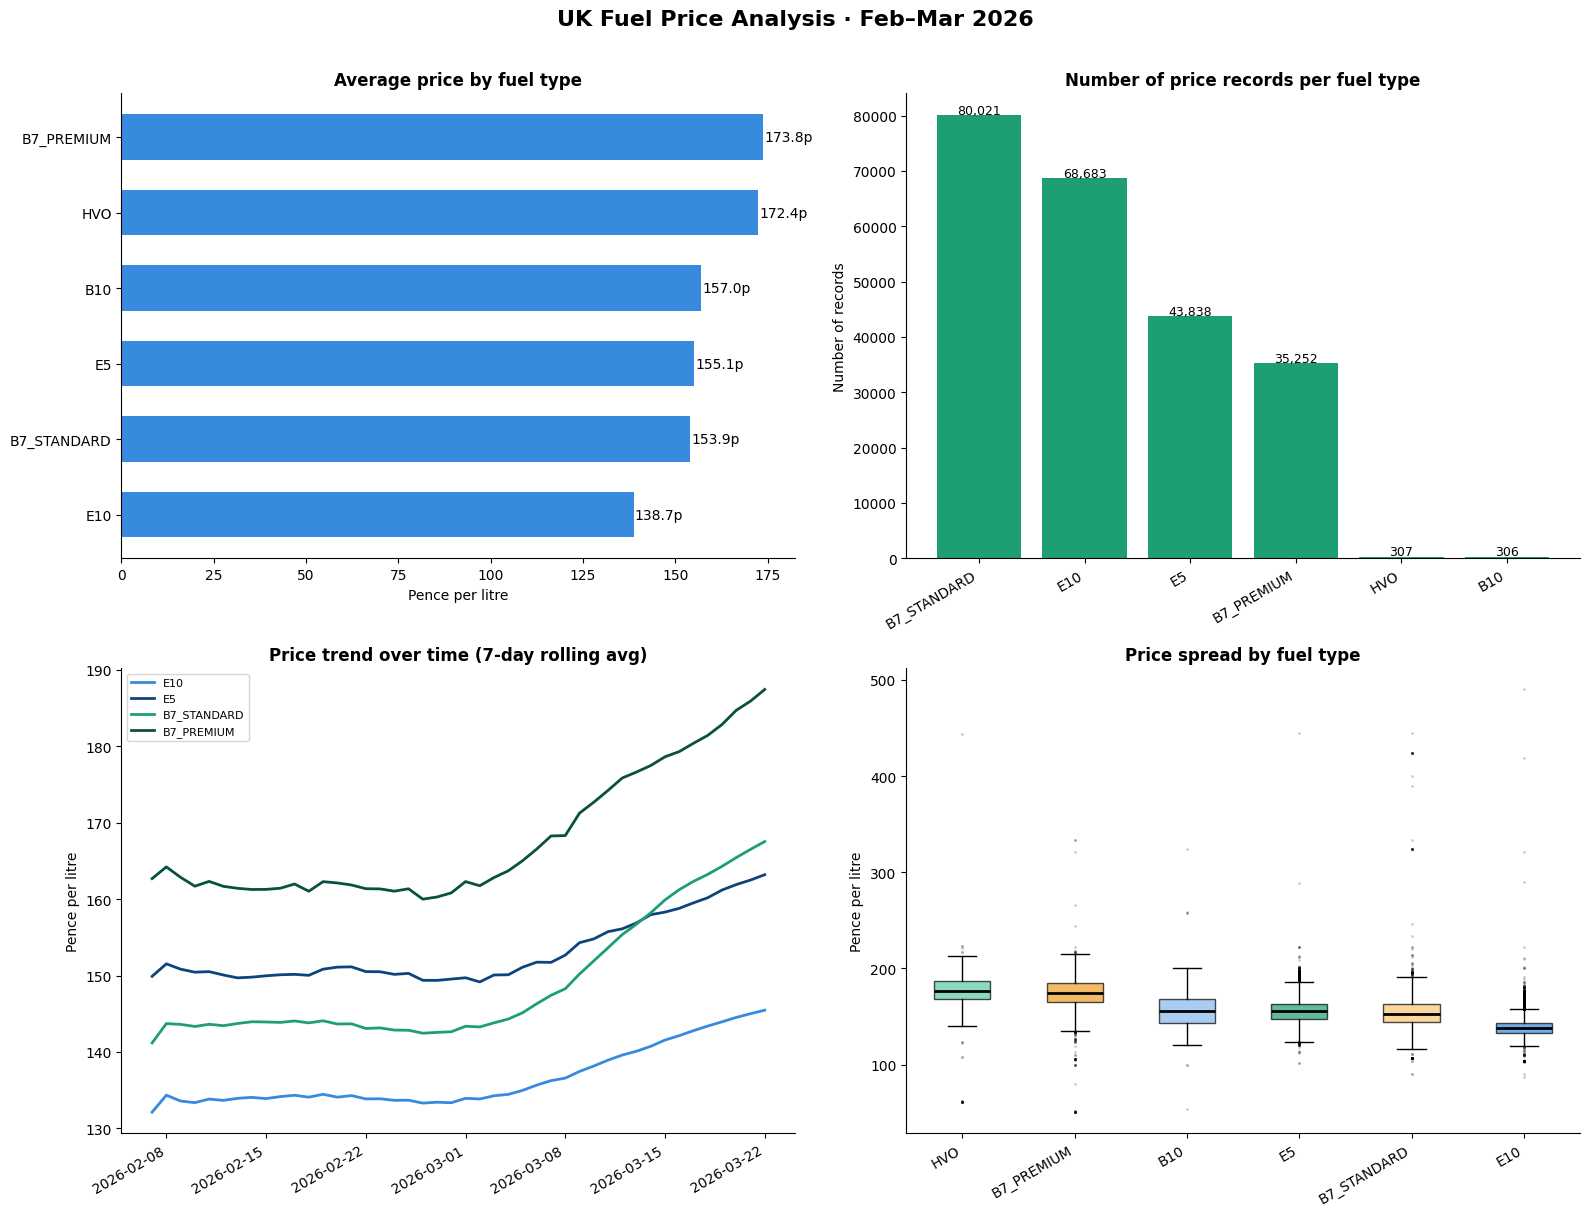

Dashboard saved as chart4_dashboard.png


In [44]:
# Cell 13 - Chart 4: Full dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('UK Fuel Price Analysis · Feb–Mar 2026', 
             fontsize=16, fontweight='bold', y=1.01)

# ── Top left: avg price bar ──────────────────────────────
ax1 = axes[0, 0]
fuel_avg = data_clean.groupby('fuel_type')['price_pence'].mean().sort_values()
ax1.barh(fuel_avg.index, fuel_avg.values, color='#378ADD', height=0.6)
for i, (idx, val) in enumerate(fuel_avg.items()):
    ax1.text(val + 0.3, i, f'{val:.1f}p', va='center', fontsize=10)
ax1.set_title('Average price by fuel type', fontweight='bold')
ax1.set_xlabel('Pence per litre')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Top right: record count bar ──────────────────────────
ax2 = axes[0, 1]
counts = data_clean['fuel_type'].value_counts()
ax2.bar(counts.index, counts.values, color='#1D9E75')
ax2.set_title('Number of price records per fuel type', fontweight='bold')
ax2.set_ylabel('Number of records')
for i, (idx, val) in enumerate(counts.items()):
    ax2.text(i, val + 200, f'{val:,}', ha='center', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Bottom left: price trend ─────────────────────────────
ax3 = axes[1, 0]
for fuel, color in colors_line.items():
    fuel_data = data_clean[data_clean['fuel_type'] == fuel].copy()
    daily = fuel_data.groupby('date')['price_pence'].mean().reset_index()
    daily['date'] = pd.to_datetime(daily['date'])
    daily['rolling'] = daily['price_pence'].rolling(7, min_periods=1).mean()
    ax3.plot(daily['date'], daily['rolling'], color=color, 
             linewidth=2, label=fuel)
ax3.set_title('Price trend over time (7-day rolling avg)', fontweight='bold')
ax3.set_ylabel('Pence per litre')
ax3.legend(fontsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Bottom right: price spread box plot ──────────────────
ax4 = axes[1, 1]
data_to_plot = [data_clean[data_clean['fuel_type'] == f]['price_pence'].values 
                for f in order]
bp = ax4.boxplot(data_to_plot, labels=order, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='.', markersize=2, alpha=0.2))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title('Price spread by fuel type', fontweight='bold')
ax4.set_ylabel('Pence per litre')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../figures/chart4_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as chart4_dashboard.png")